In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('./weatherHistory.csv')
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [3]:
df = df.drop(['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary', 'Loud Cover'], axis=1)
# Axis=1 : biar ngebaca column, bukan row
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature (C)           96453 non-null  float64
 1   Apparent Temperature (C)  96453 non-null  float64
 2   Humidity                  96453 non-null  float64
 3   Wind Speed (km/h)         96453 non-null  float64
 4   Wind Bearing (degrees)    96453 non-null  float64
 5   Visibility (km)           96453 non-null  float64
 6   Pressure (millibars)      96453 non-null  float64
dtypes: float64(7)
memory usage: 5.2 MB


In [4]:
X = df.drop(['Humidity'], axis=1)
y = df['Humidity']

In [5]:
# Train : Val : Test = 70 : 15 : 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, 
                                                train_size=0.5, 
                                                random_state=42)
print('Train:', len(X_train), 
      '\nVal:', len(X_val), 
      '\nTest:', len(X_test))

Train: 67517 
Val: 14468 
Test: 14468


In [6]:
# Supaya angka besar dan lebih kecil punya skala yang sama
scaler = StandardScaler()

In [7]:
X_train = scaler.fit_transform(X_train)  # ada fitting mean, std deviation
X_val = scaler.transform(X_val)  # ngga perlu diitung ulang lagi yg td udah difit
X_test = scaler.transform(X_test)

In [8]:
X_train.shape

(67517, 6)

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),  # column x row
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                224       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 897
Trainable params: 897
Non-trainable params: 0
_________________________________________________________________


In [12]:
mod = model.fit(X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=256,
                )

Epoch 1/50
264/264 [==============================] - 3s 7ms/step - loss: 0.0992 - mae: 0.2288 - val_loss: 0.0185 - val_mae: 0.1067
Epoch 2/50
264/264 [==============================] - 2s 7ms/step - loss: 0.0167 - mae: 0.0991 - val_loss: 0.0157 - val_mae: 0.0950
Epoch 3/50
264/264 [==============================] - 2s 7ms/step - loss: 0.0152 - mae: 0.0938 - val_loss: 0.0146 - val_mae: 0.0921
Epoch 4/50
264/264 [==============================] - 2s 6ms/step - loss: 0.0144 - mae: 0.0909 - val_loss: 0.0142 - val_mae: 0.0903
Epoch 5/50
264/264 [==============================] - 2s 7ms/step - loss: 0.0139 - mae: 0.0891 - val_loss: 0.0137 - val_mae: 0.0886
Epoch 6/50
264/264 [==============================] - 6s 23ms/step - loss: 0.0136 - mae: 0.0880 - val_loss: 0.0135 - val_mae: 0.0883
Epoch 7/50
264/264 [==============================] - 2s 7ms/step - loss: 0.0135 - mae: 0.0873 - val_loss: 0.0132 - val_mae: 0.0864
Epoch 8/50
264/264 [==============================] - 2s 7ms/step - loss: 0

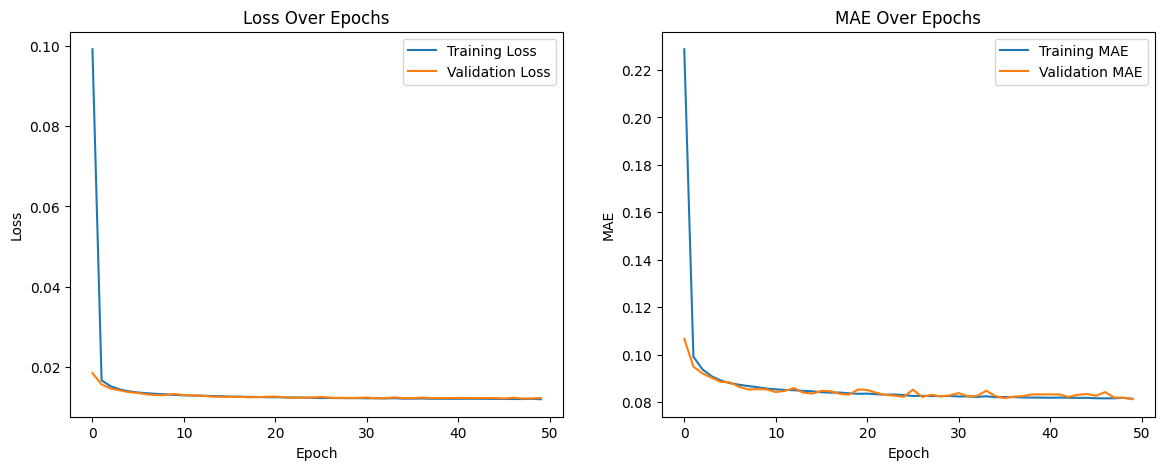

In [13]:
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.plot(mod.history['loss'], label='Training Loss')
plt.plot(mod.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(mod.history['mae'], label='Training MAE')
plt.plot(mod.history['val_mae'], label='Validation MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [14]:
test_mse, test_mae = model.evaluate(X_test, y_test)
print(f'Test MSE: {test_mse:.5f}\nTest MAE: {test_mae:.5f}')

453/453 [==============================] - 2s 4ms/step - loss: 0.0124 - mae: 0.0814
Test MSE: 0.01240
Test MAE: 0.08136


In [15]:
baseline_mse = float(((y_test - y_train.mean()) ** 2).mean())
print(f'R2: {1 - test_mse / baseline_mse:.3f}')  # semakin kecil hasilnya, semakin mirip modelnya dengan baseline model

R2: 0.674


In [16]:
X.columns

Index(['Temperature (C)', 'Apparent Temperature (C)', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)'],
      dtype='object')

In [19]:
sample = [
    9.472222222222221,7.3888888888888875,14.1197,251.0,15.826300000000002,1015.13
]

sample_df = pd.DataFrame([sample], columns=X.columns)
sample_scaled = scaler.transform(sample_df)
prediction = model.predict(sample_scaled)

print(f'Prediction Humidity: {prediction[0][0]:.5f}')

1/1 [==============================] - 0s 80ms/step
Prediction Humidity: 0.77360
